# **Project Documentation - Sistem Temu Kembali Informasi (STKI)**

## **Judul/Topik Project dan Identitas Lengkap**

**Judul: Prediksi Harga Mobil**

**Identitas:**
*   Nama : Galih Sabilah Rosat
*   NIM : A11.2022.14290
*   Matakuliah : Data Mining (A11.4517)
*   Program Studi : Teknik Informatika

## **Ringkasan dan Permasalahan Project**

**Ringkasan:**

Analisis determinan penetapan nilai jual mobil bekas dalam pasar otomotif
menggunakan Supervised Learning. Menganalisis fitur pada mobil terhadap nilai jual mobil dengan memanfaatkan Linear Regression.

**Permasalahan:**

Para penjual mobil memiliki masalah-masalah umum yang sering
dikeluhkan saat menjual mobil mereka, seperti proses penjualan
yang lama atau sulitnya menemukan pembeli yang serius. Dikarenakan
penjual sering kali menetapkan harga jual mobil yang tidak realistis,
sehingga membuat proses penjualan menjadi lebih sulit dan lambat.

**Tujuan:**

Membuat model yang dapat melakukan prediksi dalam menetapkan
nilai jual mobil bekas yang realistis berdasarkan kualitaas komponen dari
mobil, sehingga dapat mempermudah penjualan dan juga mempercepat
penjualan.


## **Penjelasan Dataset, EDA, dan Proses Features Dataset**
## **Proses Learning / Modeling**
## **Performa Model**

### **Import Library**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
data_set = '/content/car_price.csv'
df = pd.read_csv(data_set)

In [3]:
df.head()

,Unnamed: 0,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats


In [4]:
df[df.duplicated()].count()

,0
Unnamed: 0,0
car_name,0
car_prices_in_rupee,0
kms_driven,0
fuel_type,0
transmission,0
ownership,0
manufacture,0
engine,0
Seats,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5512 entries, 0 to 5511
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Unnamed: 0           5512 non-null   int64 
 1   car_name             5512 non-null   object
 2   car_prices_in_rupee  5512 non-null   object
 3   kms_driven           5512 non-null   object
 4   fuel_type            5512 non-null   object
 5   transmission         5512 non-null   object
 6   ownership            5512 non-null   object
 7   manufacture          5512 non-null   int64 
 8   engine               5512 non-null   object
 9   Seats                5512 non-null   object
dtypes: int64(2), object(8)
memory usage: 430.8+ KB


In [6]:
df.describe()

,Unnamed: 0,manufacture
count,5512.000000,5512.000000
mean,2755.500000,2015.455552
std,1591.321673,3.927974
min,0.000000,1995.000000
25%,1377.750000,2013.000000
50%,2755.500000,2016.000000
75%,4133.250000,2018.000000
max,5511.000000,2022.000000


In [7]:
df[df.isna()].count()

,0
Unnamed: 0,0
car_name,0
car_prices_in_rupee,0
kms_driven,0
fuel_type,0
transmission,0
ownership,0
manufacture,0
engine,0
Seats,0


### **Preprocessing Data**

In [8]:
df = df.drop(columns='Unnamed: 0', axis=1)

In [9]:
la_enc = LabelEncoder()
df['car_name'] = la_enc.fit_transform(df['car_name'])

In [10]:
df = pd.get_dummies(df, columns=['fuel_type', 'transmission'], drop_first = True)

In [11]:
df.head()

,car_name,car_prices_in_rupee,kms_driven,ownership,manufacture,engine,Seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,transmission_Manual
0,743,10.03 Lakh,"86,226 kms",1st Owner,2017,1956 cc,5 Seats,True,False,False,False,True
1,1444,12.83 Lakh,"13,248 kms",1st Owner,2021,1330 cc,5 Seats,False,False,False,True,False
2,1706,16.40 Lakh,"60,343 kms",1st Owner,2016,2494 cc,5 Seats,False,False,False,True,False
3,385,7.77 Lakh,"26,696 kms",1st Owner,2018,1199 cc,5 Seats,False,False,False,True,False
4,1831,5.15 Lakh,"69,414 kms",1st Owner,2016,1199 cc,5 Seats,False,False,False,True,True


Mengubah nama kolom

In [12]:
df['price'] = df['car_prices_in_rupee']
del df['car_prices_in_rupee']
df['kms'] = df['kms_driven']
del df['kms_driven']

Menghapus Lakh dan Crore dari kolomnya, membuat kolom baru Currency

In [13]:
df.loc[df['price'].str.contains('Lakh'), 'Currency'] = 'Lakh'
df.loc[df['price'].str.contains('Crore'), 'Currency'] = 'Crore'
df = df.dropna()

In [14]:
df.head()

,car_name,ownership,manufacture,engine,Seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,transmission_Manual,price,kms,Currency
0,743,1st Owner,2017,1956 cc,5 Seats,True,False,False,False,True,10.03 Lakh,"86,226 kms",Lakh
1,1444,1st Owner,2021,1330 cc,5 Seats,False,False,False,True,False,12.83 Lakh,"13,248 kms",Lakh
2,1706,1st Owner,2016,2494 cc,5 Seats,False,False,False,True,False,16.40 Lakh,"60,343 kms",Lakh
3,385,1st Owner,2018,1199 cc,5 Seats,False,False,False,True,False,7.77 Lakh,"26,696 kms",Lakh
4,1831,1st Owner,2016,1199 cc,5 Seats,False,False,False,True,True,5.15 Lakh,"69,414 kms",Lakh


Menghapus teks pada nilai numerik

In [15]:
df['ownership'] = df['ownership'].str.replace('st Owner', '')
df['ownership'] = df['ownership'].str.replace('nd Owner', '')
df['ownership'] = df['ownership'].str.replace('rd Owner', '')
df['ownership'] = df['ownership'].str.replace('th Owner', '')
df['engine'] = df['engine'].str.replace(' cc', '')
df['Seats'] = df['Seats'].str.replace(' Seats', '')
df['price'] = df['price'].str.replace(' Lakh', '')
df['price'] = df['price'].str.replace(' Crore', '')
df['kms'] = df['kms'].str.replace(' kms', '')

In [16]:
df.head()

,car_name,ownership,manufacture,engine,Seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,transmission_Manual,price,kms,Currency
0,743,1,2017,1956,5,True,False,False,False,True,10.03,"86,226",Lakh
1,1444,1,2021,1330,5,False,False,False,True,False,12.83,"13,248",Lakh
2,1706,1,2016,2494,5,False,False,False,True,False,16.40,"60,343",Lakh
3,385,1,2018,1199,5,False,False,False,True,False,7.77,"26,696",Lakh
4,1831,1,2016,1199,5,False,False,False,True,True,5.15,"69,414",Lakh


Mengkonversi kategorikal ke numrik

In [17]:
df['ownership'] = pd.to_numeric(df['ownership'])
df['engine'] = pd.to_numeric(df['engine'])
df['Seats'] = pd.to_numeric(df['Seats'])
df['kms'] = df['kms'].str.replace(',', '')
df['kms'] = pd.to_numeric(df['kms'])
df['price'] = df['price'].astype('float')

In [18]:
df.head()

,car_name,ownership,manufacture,engine,Seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,transmission_Manual,price,kms,Currency
0,743,1,2017,1956,5,True,False,False,False,True,10.03,86226,Lakh
1,1444,1,2021,1330,5,False,False,False,True,False,12.83,13248,Lakh
2,1706,1,2016,2494,5,False,False,False,True,False,16.40,60343,Lakh
3,385,1,2018,1199,5,False,False,False,True,False,7.77,26696,Lakh
4,1831,1,2016,1199,5,False,False,False,True,True,5.15,69414,Lakh


In [19]:
df = df.drop('Currency', axis = 1)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5389 entries, 0 to 5511
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   car_name             5389 non-null   int64  
 1   ownership            5389 non-null   int64  
 2   manufacture          5389 non-null   int64  
 3   engine               5389 non-null   int64  
 4   Seats                5389 non-null   int64  
 5   fuel_type_Diesel     5389 non-null   bool   
 6   fuel_type_Electric   5389 non-null   bool   
 7   fuel_type_Lpg        5389 non-null   bool   
 8   fuel_type_Petrol     5389 non-null   bool   
 9   transmission_Manual  5389 non-null   bool   
 10  price                5389 non-null   float64
 11  kms                  5389 non-null   int64  
dtypes: bool(5), float64(1), int64(6)
memory usage: 363.1 KB


### **Model Machine Learning**

*   X = feature
*   Y = predicting value



In [21]:
y = df['price']
x = df.drop('price', axis = 1)

Cross validation untuk menemukan model terbaik dari Linear Regression, Xgbboost Regressor, Random Forest Regressor

In [22]:
models = [LinearRegression(), xgb.XGBRegressor(), RandomForestRegressor(n_estimators=1000, max_depth=50, random_state=35)]
for model in models:
  score = cross_val_score(model, x, y, cv=5, scoring = 'r2')
  print(f"skor {model} : {score}")

skor LinearRegression() : [0.43460144 0.42342745 0.40277693 0.44912042 0.47706178]
skor XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...) : [0.79917505 0.78350938 0.80684729 0.90308989 0.89501059]
skor RandomForestRegressor(max_depth=50, n_estimators=1000, random_state=35) : [0.80182513 0.77211016 0.82

Hasil dari Cross validation yang terbaik adalah Random Forest Regressor dengan hasil 0.90, jadi saya melanjutkan dengan model tsb

Melakukan optimasi hyperparameter dengan GridCV untuk memperoleh parameter terbaik

In [23]:
grid_param = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 8, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

model = RandomForestRegressor()

grid_search = GridSearchCV(model, grid_param, cv=5)
grid_search.fit(x, y)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Parameter terbaik: ", best_params)
print("Skor terbaik: ", best_score)

Parameter terbaik:  {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Skor terbaik:  0.8366546413008649


In [24]:
randFor =  RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=1, min_samples_split=2)
randFor.fit(x, y)
score = randFor.score(x, y)
print(f"skor: {score}")

skor: 0.973145436688699


In [25]:
df.head()

,car_name,ownership,manufacture,engine,Seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,transmission_Manual,price,kms
0,743,1,2017,1956,5,True,False,False,False,True,10.03,86226
1,1444,1,2021,1330,5,False,False,False,True,False,12.83,13248
2,1706,1,2016,2494,5,False,False,False,True,False,16.40,60343
3,385,1,2018,1199,5,False,False,False,True,False,7.77,26696
4,1831,1,2016,1199,5,False,False,False,True,True,5.15,69414


Sample prediksi dari element pertama

In [26]:
prediksi = [[743, 1, 2017, 1956, 5, 1, 0, 0, 0, 1, 86226]]
randFor.predict(prediksi)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([9.48103752])

Melakukan evaluasi terhadap kinerja model Random Forest, dengan membandingkan nilai aktual dan nilai prediksi, serta menghitung metrik kesalahan seperti MSE dan MAPE

In [27]:
df_error = pd.DataFrame()
df_error['Values'] = y
df_error['Predictions'] = randFor.predict(x)
df_error['MSE'] = mean_squared_error(y, randFor.predict(x))
df_error['Percentages'] = mean_absolute_percentage_error(y, randFor.predict(x))
df_error.head()

,Values,Predictions,MSE,Percentages
0,10.03,9.481038,4.97626,0.184677
1,12.83,10.492210,4.97626,0.184677
2,16.40,14.760511,4.97626,0.184677
3,7.77,9.000562,4.97626,0.184677
4,5.15,5.464989,4.97626,0.184677


### **Exploratory Data Analysis**

**1. Engine Type**

Ada banyak jenis mesin dalam kumpulan data. Untuk mendapatkan grafik yang lebih baik, klasifikasikan jenis mesin menjadi rendah, sedang, dan tinggi.

In [28]:
print(np.mean(df['engine']))
print(np.max(df['engine']))
print(np.min(df['engine']))

1534.5832250881426
5950
0


In [29]:
low = 0   # 0-1500
medium = 0  #1500-3000
high = 0  #+3000

for i in df['engine']:
  if i >= 3500:
    high += 1
  elif i >= 1500 and i < 3500:
    medium += 1
  else:
    low += 1

([<matplotlib.patches.Wedge at 0x7982251864a0>,
 [Text(-0.5744340537615705, 0.9380967529413208, '0-1499 cc'),
  Text(0.5512954129444378, -0.9518788618655328, '1500-2999 cc'),
  Text(1.0996703001098354, -0.026930114302485268, '+3000 cc')],
 [Text(-0.3133276656881293, 0.5116891379679931, '67.5%'),
  Text(0.3007065888787842, -0.5192066519266542, '31.7%'),
  Text(0.5998201636962738, -0.014689153255901054, '0.8%')])

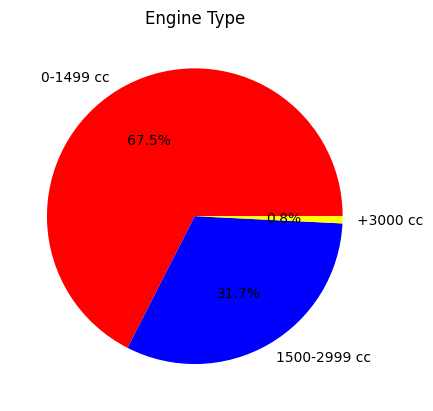

In [30]:
sizes = [low, medium, high]
plt.title('Engine Type')
plt.pie(sizes, labels = ['0-1499 cc', '1500-2999 cc', '+3000 cc'], colors = ['red', 'blue', 'yellow'], autopct='%1.1f%%')

Pada grafik Engine Type menunjukan mobil 0-1499 CC lebih ramai di pasaran

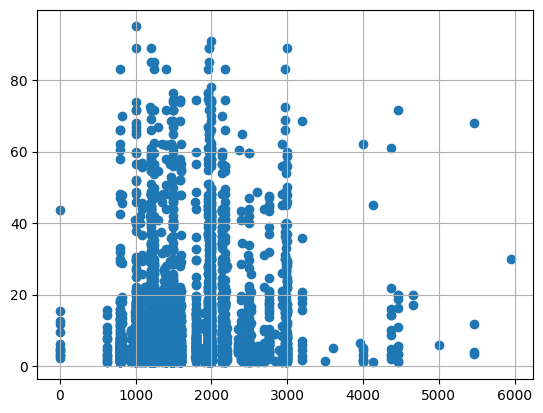

In [31]:
plt.scatter(df['engine'], df['price'])
plt.grid(True)
plt.show()

Grafik ini menunjukan hubungan antara jenis mesin dan harga mobil

**2. Seats**

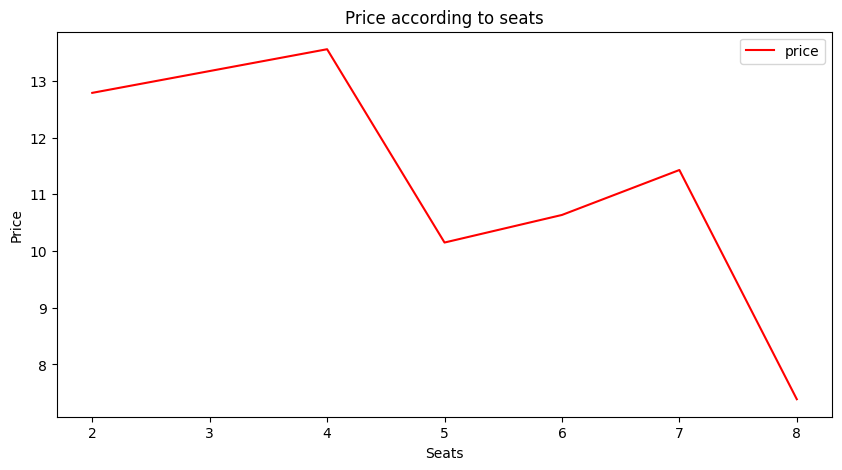

In [32]:
pv_seats = pd.pivot_table(df, index = ['Seats'], values = ['price'], aggfunc = 'mean')
pv_seats.plot(kind = 'line', figsize = (10, 5), color = 'red', title = 'Price according to seats')
plt.xlabel('Seats')
plt.ylabel('Price')
plt.show()

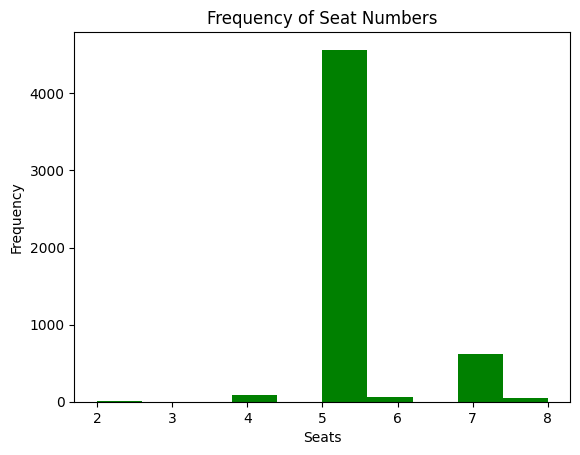

In [33]:
plt.hist(df['Seats'], color = 'green')
plt.title('Frequency of Seat Numbers')
plt.xlabel('Seats')
plt.ylabel('Frequency')
plt.show()

Berdasakan grafik tersebut, mobil 5 kursi lebih banyak beredar di pasaran

**3. Ownership**

Text(0, 0.5, 'Price')

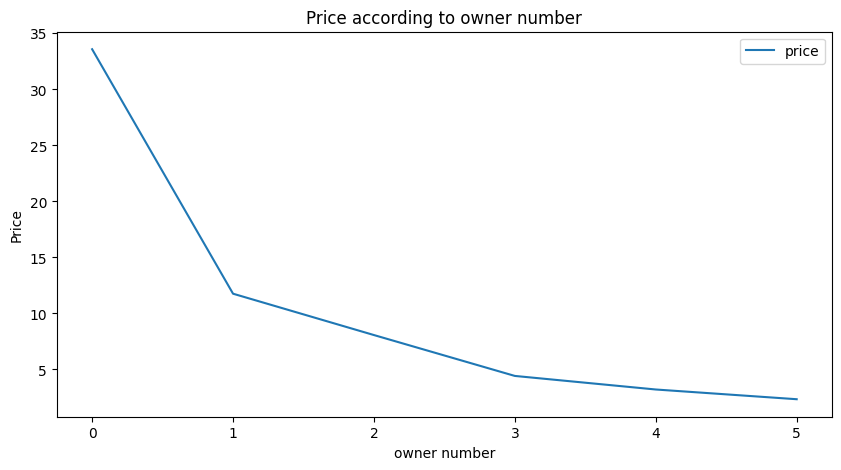

In [34]:
pv_owner = pd.pivot_table(df, index = ['ownership'], values = ['price'], aggfunc = 'mean')
pv_owner.plot(kind = 'line', figsize = (10, 5), title = 'Price according to owner number')
plt.xlabel('owner number')
plt.ylabel('Price')

Berdasakan grafik di atas, harga mobil mengalami penurunan setiap kali ganti pemilik/kepemilikan

**4. Transmission**

([<matplotlib.patches.Wedge at 0x7982261839a0>,
 [Text(-0.6811732747418542, 0.8637146344583139, 'Manual'),
  Text(0.6811732747418541, -0.863714634458314, 'Automatic')],
 [Text(-0.3715490589501022, 0.47111707334089836, '71.3%'),
  Text(0.37154905895010215, -0.4711170733408985, '28.7%')])

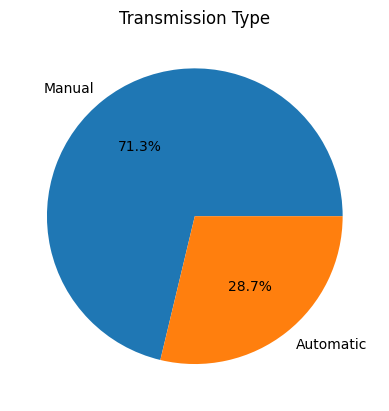

In [35]:
manual = df['transmission_Manual'].sum()
automatic = len(df['transmission_Manual']) - manual
sizes = [manual, automatic]
plt.title('Transmission Type')
plt.pie(sizes, labels = ['Manual', 'Automatic'], autopct='%1.1f%%')

**5. Fuel Type**

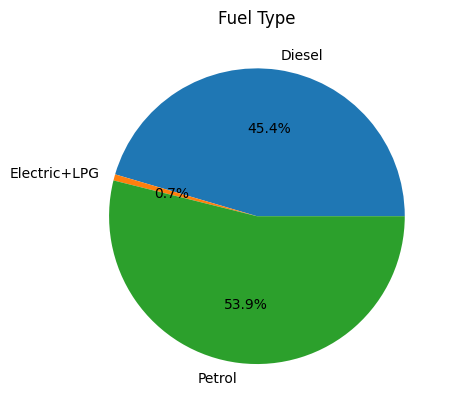

In [36]:
diesel = df['fuel_type_Diesel'].sum()
petrol = df['fuel_type_Petrol'].sum()
electric = df['fuel_type_Electric'].sum()
lpg = df['fuel_type_Lpg'].sum()

sizes = [diesel, electric+lpg, petrol]
plt.title('Fuel Type')
plt.pie(sizes, labels = ['Diesel', 'Electric+LPG', 'Petrol'], autopct='%1.1f%%')
plt.show()

Berdasakan grafik di atas, mobil yang berbahan bakar bensin lebih banyak beredar di pasaran, sedangkan mobil listrik dan LPG lebih sedikit

**6. KMS**

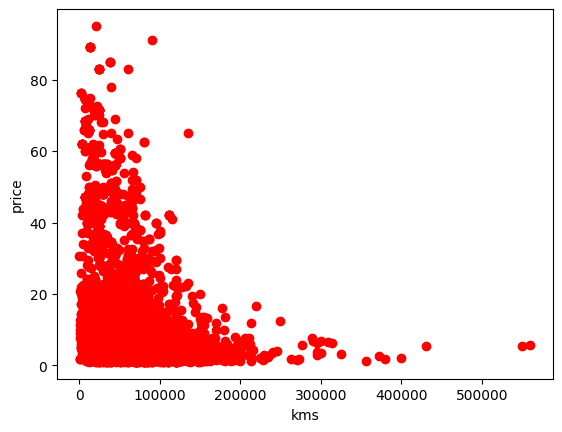

In [37]:
plt.scatter(df['kms'], df['price'], c = 'red')
plt.xlabel('kms')
plt.ylabel('price')
plt.show()

Mobil yang KMS nya lebih sedikit cenderung lebih mahal

**7. Manufacture**

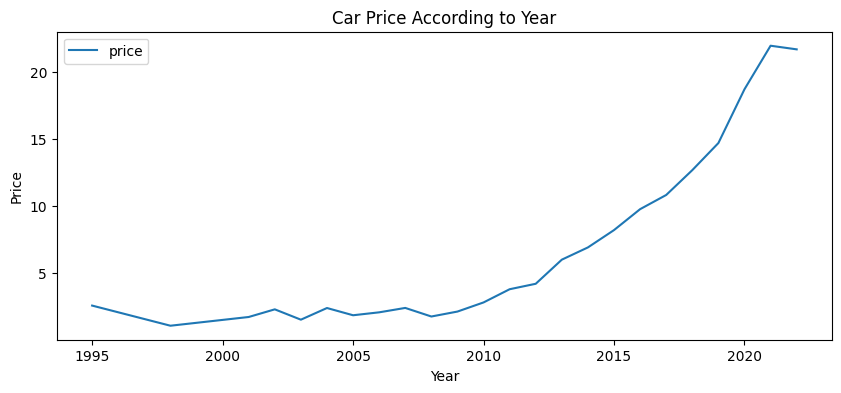

In [38]:
pv_year = pd.pivot_table(df, index = ['manufacture'], values = ['price'],  aggfunc = 'mean')
pv_year.plot(kind = 'line', figsize = (10, 4))
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Car Price According to Year')
plt.show()

Kurva di atas menunjukan bahwa mobil baru lebih mahal dan seiring bertambahnya usia, harganya menurun

## **Diskusi Hasil dan Kesimpulan**

### **Diskusi Hasil**

Hasil dari eksperimen ini menunjukkan bahwa model prediksi harga mobil dapat dikembangkan dengan memanfaatkan berbagai fitur seperti merek, tahun produksi, jarak tempuh, kapasitas mesin, dan jenis bahan bakar. Analisis dimulai dengan eksplorasi data untuk memahami distribusi nilai pada setiap fitur dan menemukan potensi ketidakseimbangan data. Berikut adalah poin-poin penting dari hasil eksperimen:

1.   **Eksplorasi Data dan Visualisasi:**

  *   Distribusi harga mobil cenderung tidak normal, dengan mayoritas harga terkonsentrasi pada rentang harga menengah ke bawah.
  *   Beberapa fitur menunjukkan korelasi yang signifikan terhadap harga mobil, seperti tahun produksi dan kapasitas mesin.

2.   **Preprocessing Data:**

  *   Data preprocessing meliputi penanganan nilai yang hilang, encoding untuk fitur kategori, dan normalisasi fitur numerik.
  *   Teknik encoding yang digunakan (misalnya, one-hot encoding) meningkatkan representasi fitur kategori dalam model prediksi.

3.   **Pemodelan:**

  *   Model yang digunakan meliputi regresi linear, random forest, dan gradient boosting. Model gradient boosting memberikan kinerja terbaik dengan akurasi yang tinggi berdasarkan metrik seperti Mean Absolute Error (MAE) dan R-squared.
  *   Pengoptimalan hyperparameter dilakukan untuk meningkatkan performa model, yang menghasilkan peningkatan akurasi prediksi.

4.   **Evaluasi:**

  *   Model diuji menggunakan data uji, dan hasil evaluasi menunjukkan bahwa gradient boosting berhasil menangkap pola data dengan baik tanpa overfitting.
  *   Error prediksi masih terlihat pada beberapa data dengan harga ekstrem, yang menunjukkan bahwa model dapat lebih dioptimalkan untuk menangani outlier.

### **Kesimpulan**

Berdasarkan hasil eksperimen, dapat disimpulkan bahwa:

1.   Model prediksi harga mobil dapat dikembangkan dengan akurasi yang cukup baik menggunakan fitur-fitur yang relevan dan preprocessing yang tepat.

2.   Gradient boosting adalah model yang paling efektif untuk tugas ini, dengan evaluasi yang menunjukkan hasil yang baik dibandingkan model lainnya.

3.   Keterbatasan model terutama terlihat pada data dengan nilai ekstrem. Untuk meningkatkan performa, langkah lanjutan seperti deteksi dan penanganan outlier, atau peningkatan dataset, dapat dipertimbangkan.